

# =====================================================
# Healthcare Data Analysis for Diabetes Prediction
# using Machine Learning and Feature Importance
# =====================================================

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [ ]:
# Load Dataset

df = pd.read_csv("/content/diabetes.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies            

In [ ]:
# Data Preprocessing

# Replace invalid zeros with median values
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zero:
    df[col] = df[col].replace(0, df[col].median())

In [ ]:
# Feature and Target Variables

X = df.drop("Outcome", axis=1)
y = df["Outcome"]



# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# RANDOM FOREST CLASSIFIER


rf_model = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring='accuracy'
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_


In [ ]:
# DECISION TREE CLASSIFIER


dt_model = DecisionTreeClassifier(random_state=42)

dt_params = {
    'max_depth': [3, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    dt_model,
    dt_params,
    cv=5,
    scoring='accuracy'
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_


In [ ]:
# LOGISTIC REGRESSION


lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

lr_params = {
    'lr__C': [0.1, 1, 10]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=5,
    scoring='accuracy'
)

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

In [ ]:
# MODEL EVALUATION FUNCTION


def evaluate_model(model, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("\n================================")
    print(f"{model_name} Results")
    print("================================")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC AUC  :", roc_auc)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


    # Confusion Matrix

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ROC Curve

    fpr, tpr, threshold = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

    plt.plot([0,1], [0,1], linestyle='--')

    plt.title(f"{model_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.show()

    return accuracy, precision, recall, f1, roc_auc



Random Forest Results
Accuracy : 0.7402597402597403
Precision: 0.6666666666666666
Recall   : 0.5185185185185185
F1 Score : 0.5833333333333334
ROC AUC  : 0.8127777777777778

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.86      0.81       100
           1       0.67      0.52      0.58        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



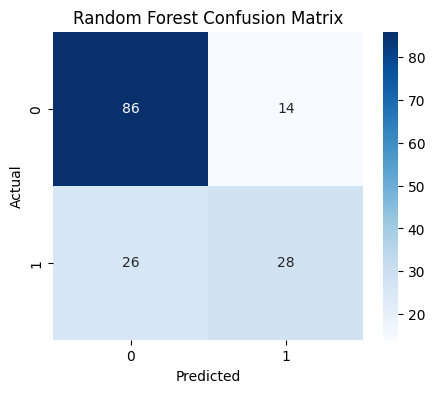

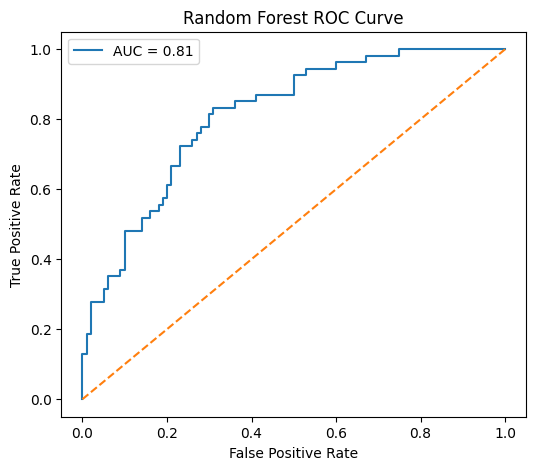


Decision Tree Results
Accuracy : 0.6948051948051948
Precision: 0.6521739130434783
Recall   : 0.2777777777777778
F1 Score : 0.38961038961038963
ROC AUC  : 0.7686111111111111

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.92      0.80       100
           1       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



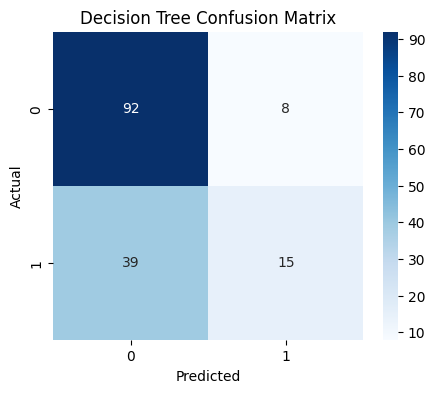

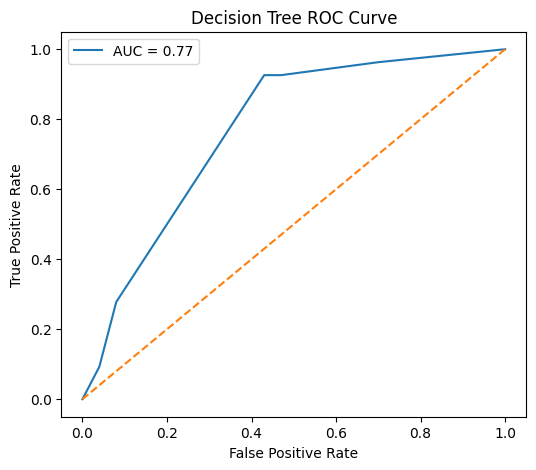


Logistic Regression Results
Accuracy : 0.7012987012987013
Precision: 0.5869565217391305
Recall   : 0.5
F1 Score : 0.54
ROC AUC  : 0.8153703703703704

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



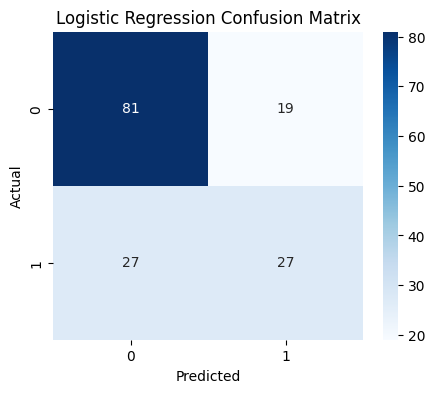

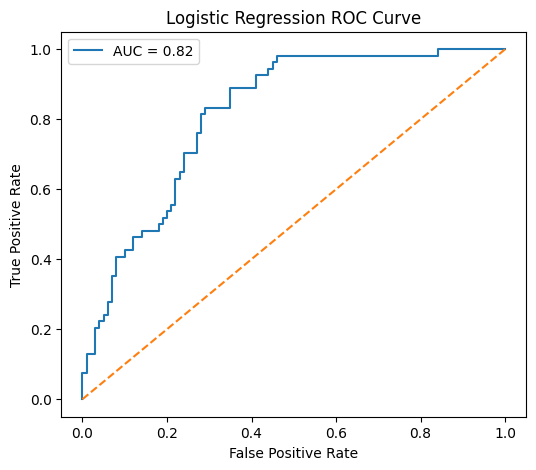


FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0        Random Forest  0.740260   0.666667  0.518519  0.583333  0.812778
1        Decision Tree  0.694805   0.652174  0.277778  0.389610  0.768611
2  Logistic Regression  0.701299   0.586957  0.500000  0.540000  0.815370


In [ ]:
# Evaluate Models


rf_results = evaluate_model(best_rf, "Random Forest")

dt_results = evaluate_model(best_dt, "Decision Tree")

lr_results = evaluate_model(best_lr, "Logistic Regression")

# FINAL COMPARISON TABLE


results_df = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [rf_results[0], dt_results[0], lr_results[0]],
    'Precision': [rf_results[1], dt_results[1], lr_results[1]],
    'Recall': [rf_results[2], dt_results[2], lr_results[2]],
    'F1 Score': [rf_results[3], dt_results[3], lr_results[3]],
    'ROC AUC': [rf_results[4], dt_results[4], lr_results[4]]
})

print("\n================================")
print("FINAL MODEL COMPARISON")
print("================================")

print(results_df)


In [ ]:
# FEATURE IMPORTANCE ANALYSIS


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)




Feature Importance:
                    Feature  Importance
1                   Glucose    0.386319
5                       BMI    0.168873
7                       Age    0.115367
6  DiabetesPedigreeFunction    0.083985
0               Pregnancies    0.073111
4                   Insulin    0.069530
2             BloodPressure    0.052722
3             SkinThickness    0.050094


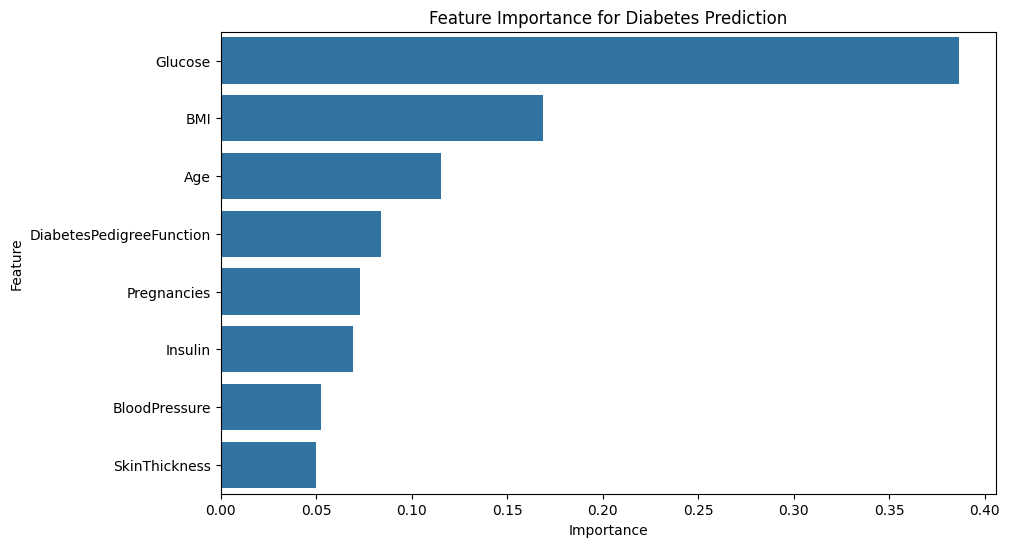

In [ ]:
# Feature Importance Graph

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance for Diabetes Prediction")

plt.show()

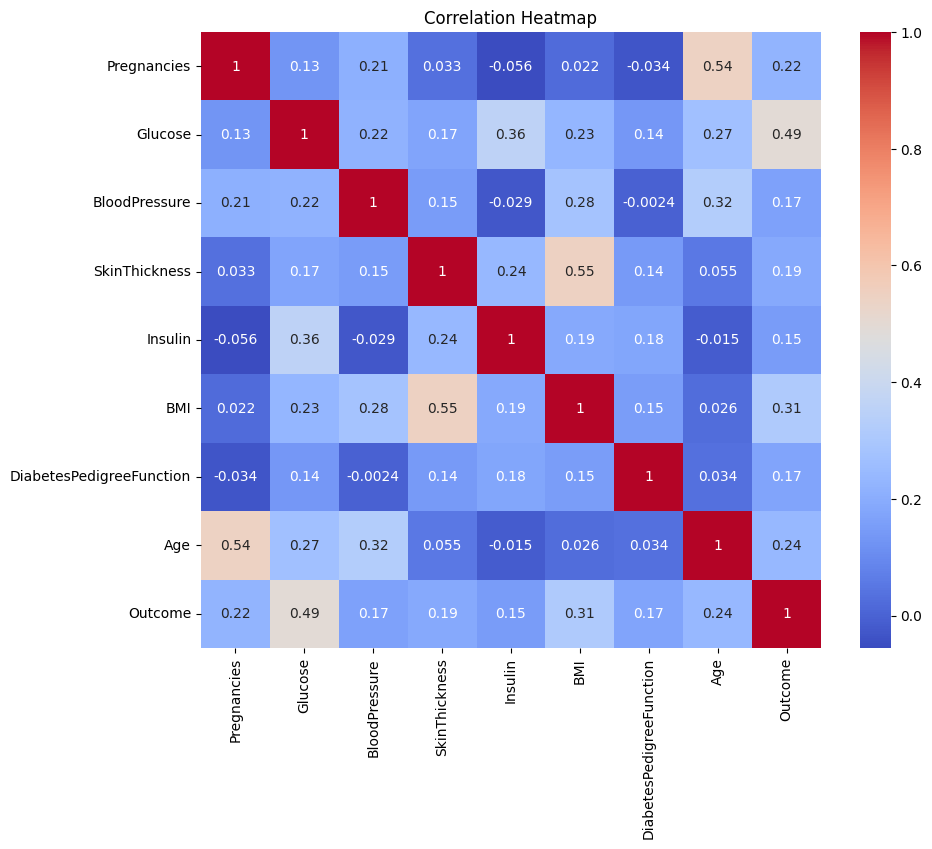

In [ ]:
# CORRELATION HEATMAP


plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()